### Coursework Question 2

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import logsumexp

#### Run the model

Firstly we will generate a synthetic dataset using the models stated in the question:

$X_n = \rho X_{n-1} + \tau V_n$

$Y_n^1 = X_n + \sigma W_n$

$Y_n^2 = X_n + \sigma \exp(\frac{X_n}{2}) W_n$


Best found: 2,4,6,8

In [194]:
def generate_data(T):

    sigma = 1
    rho = 0.8
    tau = 0.5

    # Generate initial value of x randomly from N(0,1) and set seed for reproducibility
    rng1 = np.random.default_rng(1)
    x0 = stats.norm.rvs(random_state=rng1)

    # Generate values of noise for V and W
    rng2 = np.random.default_rng(2)
    v = stats.norm.rvs(size=T,random_state=rng2)
    
    rng3 = np.random.default_rng(3)
    w1 = stats.norm.rvs(size=T+1,random_state=rng3)

    rng4 = np.random.default_rng(4)
    w2 = stats.norm.rvs(size=T+1,random_state=rng4)

    # Arrays to store hidden state (x) and observations (y)
    x = np.zeros(T+1)
    x[0] = x0
    y1 = np.zeros(T+1)
    y2 = np.zeros(T+1)
    y1[0] = x0 + sigma*w1[0]
    y2[0] = x0 + sigma*np.exp(x0/2)*w2[0]

    # Recursively calculate hidden state and observations
    for i in range(1,T+1):
        x[i] = rho*x[i-1] + tau*v[i-1]
        y1[i] = x[i] + sigma*w1[i]
        y2[i] = x[i] + sigma*np.exp(x[i]/2)*w2[i]

    return x,y1,y2

In [195]:
x,y1,y2 = generate_data(100)

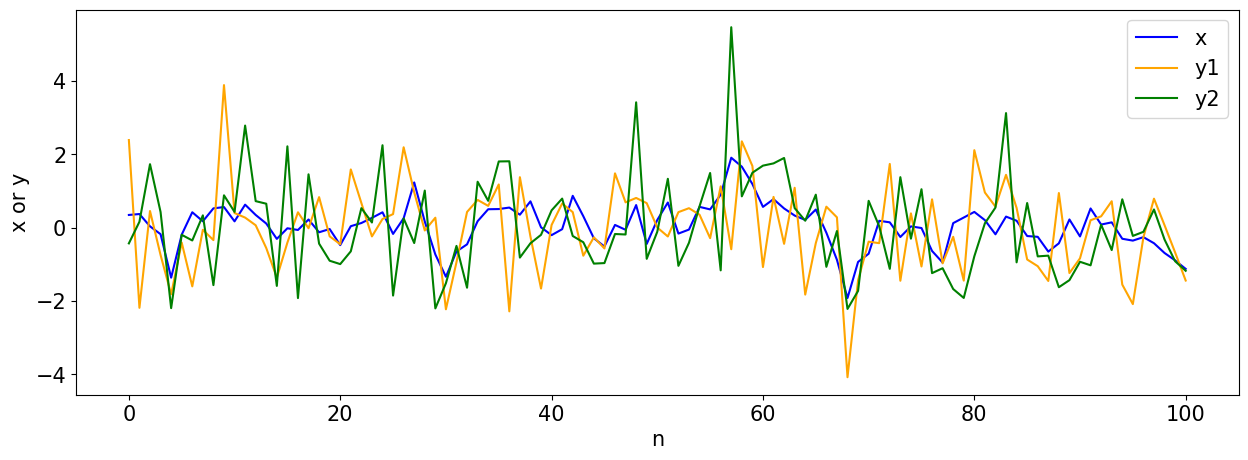

In [228]:
timesteps = np.arange(0,101)
plt.figure(figsize=(15,5))
plt.plot(timesteps,x,color="blue",label="x")
plt.plot(timesteps,y1,color="orange",label="y1")
plt.plot(timesteps,y2,color="green",label="y2")
plt.xlabel("n",fontsize=15)
plt.ylabel("x or y",fontsize=15)
plt.tick_params(labelsize=15)
plt.legend(fontsize=15)

#### SIR Particle Filter

For this question, we will use the Bootstrap proposal, so we don't need a separate function for the proposal:

Model 1: $f(x_n|x_{n-1}) = N(\rho x_{n-1}, \tau^2)$ and $g(y_n|x_n) = N(x_n, \sigma^2)$, so the proposal mean is $\rho x_{n-1}$ and variance is $\tau^2$.

Model 2: $f(x_n|x_{n-1}) = N(\rho x_{n-1}, \tau^2)$, and $g(y_n|x_n) = N(x_n, \sigma^2 \exp(\frac{x_n}{2})^2)$, so proposal mean is $\rho x_{n-1}$ and variance is $\tau^2$.

In [6]:
def prop_mean_var(x_prev,rho,tau):

    mean = rho*x_prev
    var = tau**2

    return mean, var

In [7]:
def log_g(x,y,sigma2,model):

    if model==1:
        mean = x
        var = sigma2

    else:
        mean = x
        var = sigma2*np.exp(x/2)**2
    
    val = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(y-mean)**2
    
    return val

In [8]:
def resample(omega, X, rng):

    # Number of particles
    N = len(X[:,0])

    # Sample offspring from a multinomial distribution with probabilities equal to weights omega
    copies = stats.multinomial.rvs(N,omega,random_state=rng)

    new_X = np.zeros(X.shape)

    # Make new particles by copying each old particle a number of times equal to 'copies'
    k = 0
    for i in range(N):
        if copies[i]>0:
            for _ in range(copies[i]):
                new_X[k,:] = X[i,:]
                k = k+1

    return new_X

In [58]:
def SIR(y,N,sigma2,model,run_number):

    # Set parameter values
    sigma2 = sigma2
    rho = 0.8
    tau = 0.5

    # Get the full length of the sequence
    T = len(y)

    # Set array to store the particle history and unnormalised weights at each time step
    X = np.zeros((N,T))
    unnormalised_weights = np.zeros((N,T))
    samples = np.zeros((N,T))
    weights = np.zeros((N,T))

    # TIME 0
    # Sample from initial proposal (N(0,1))
    rng = np.random.default_rng(seed=run_number)
    X[:,0] = stats.norm.rvs(size=N,random_state=rng)
    samples[:,0] = X[:,0]
        
    # Calculated log unnormalised weights and store them
    log_omega = log_g(X[:,0],y[0],sigma2,model)
    unnormalised_weights[:,0] = log_omega 

    # Normalise weights and resample particles
    max_val = np.max(log_omega)
    omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
    weights[:,0] = omega
    X = resample(omega,X,rng)

    # TIME n>0
    for n in range(1,T):
        
        m,S = prop_mean_var(X[:,n-1],rho,tau)
        rng = np.random.default_rng(seed=n+run_number)
        X[:,n] = stats.norm.rvs(loc=m,scale=np.sqrt(S),random_state=rng)
        samples[:,n] = X[:,n]
        
        log_omega = log_g(X[:,n],y[n],sigma2,model)
        unnormalised_weights[:,n] = log_omega
        
        max_val = np.max(log_omega)
        omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
        weights[:,n] = omega
        X = resample(omega,X,rng)

    return unnormalised_weights, X, samples, weights

In [10]:
def compute_marginal_likelihood(log_weights):

    N = log_weights.shape[0]
    log_p = logsumexp(log_weights,axis=0) - np.log(N)
    log_marginal_likelihood = np.sum(log_p)

    return log_marginal_likelihood

Function to run experiment: run filter and compute marginal likelihood for a grid of $\sigma^2$, returning the marginal likelihoods and the MLE:

In [16]:
def experiment(y,model,sigma2_values):
    
    likelihoods = []
    
    for sigma2 in sigma2_values:
        unnormalised_weights, X, samples, weights = SIR(y,N=500,sigma2=sigma2,model=model,run_number=0)
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)
        likelihoods.append(log_marginal_likelihood)

    mle = sigma2_values[likelihoods.index(max(likelihoods))]
    return likelihoods, mle

For model 1 and dataset 1:

In [44]:
sigma2_values = np.linspace(0.01,2,200)

In [197]:
likelihoods11, mle11 = experiment(y1,model=1,sigma2_values=sigma2_values)

For model 2 and dataset 1:

In [198]:
likelihoods21, mle21 = experiment(y1,model=2,sigma2_values=sigma2_values)

For model 1 and dataset 2:

In [199]:
likelihoods12, mle12 = experiment(y2,model=1,sigma2_values=sigma2_values)

For model 2 and dataset 2:

In [200]:
likelihoods22, mle22 = experiment(y2,model=2,sigma2_values=sigma2_values)

#### Kalman Filter

In [21]:
def kalman_filter(y,sigma2):

    rho = 0.8
    tau = 0.5

    # Get length of observation sequence
    T = len(y)

    # Set arrays to store mu_a (mu_n|n), var_a, mu_b (mu_n|n-1), var_b, m and S
    mu_a = np.zeros(T)
    var_a = np.zeros(T)
    mu_b = np.zeros(T)
    var_b = np.zeros(T)
    m = np.zeros(T)
    S = np.zeros(T)

    # Set initial values of mu_a and sigma_a
    # Use the first observation as the first mean and the known standard deviation as the first sigma
    mu_init = 0
    var_init = 1

    # Implement Kalman filter equations recursively, using mu_init and var_init to calculate mu_b and var_b on the first step
    for i in range(T):
        if i==0:
            mu_b[i] = rho*mu_init
            var_b[i] = rho**2*var_init + tau**2
        else:
            mu_b[i] = rho*mu_a[i-1]
            var_b[i] = rho**2*var_a[i-1] + tau**2
            
        m[i] = mu_b[i]
        S[i] = var_b[i] + sigma2
        K = var_b[i]*1/S[i]
        mu_a[i] = mu_b[i] + K*(y[i]-m[i])
        var_a[i] = var_b[i] - K*var_b[i]

    # For computing marginal likelihood, we only need m and S
    return mu_a, var_a, mu_b, var_b, m, S

In [22]:
def compute_ideal_marginal_likelihood(y,m,S):

    # Normal distribution with mean m and variance S at each step
    log_p = -1/2*np.log(2*np.pi*S) - 1/(2*S)*(y-m)**2

    # Compute log marginal likelihood by adding log probabilities
    log_marginal_likelihood = np.sum(log_p)

    return log_marginal_likelihood

Check that SIR matches Kalman Filter:

In [201]:
mu_a, var_a, mu_b, var_b, m, S = kalman_filter(y1,sigma2=1)

In [202]:
unnormalised_weights, X, samples, weights = SIR(y1,N=500,sigma2=1,model=1,run_number=0)

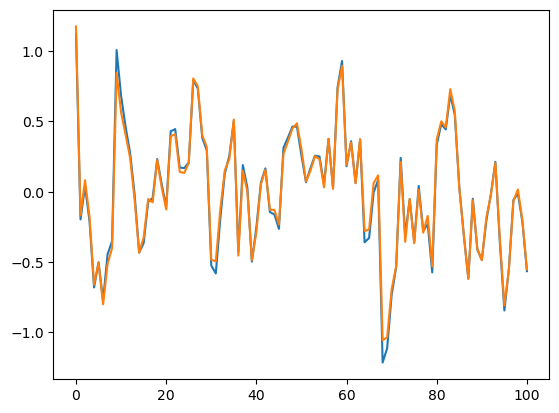

In [203]:
plt.plot(timesteps,mu_a)
plt.plot(timesteps,np.sum(samples*weights,axis=0))

In [52]:
def experiment2(y,sigma2_values):
    
    likelihoods = []
    
    for sigma2 in sigma2_values:
        mu_a, var_a, mu_b, var_b, m, S = kalman_filter(y,sigma2)
        log_marginal_likelihood = compute_ideal_marginal_likelihood(y,m,S)
        likelihoods.append(log_marginal_likelihood)

    mle = sigma2_values[likelihoods.index(max(likelihoods))]
    return likelihoods, mle

In [204]:
likelihoods_a, mle_a = experiment2(y1,sigma2_values)

In [205]:
likelihoods_b, mle_b = experiment2(y2,sigma2_values)

For dataset 1:

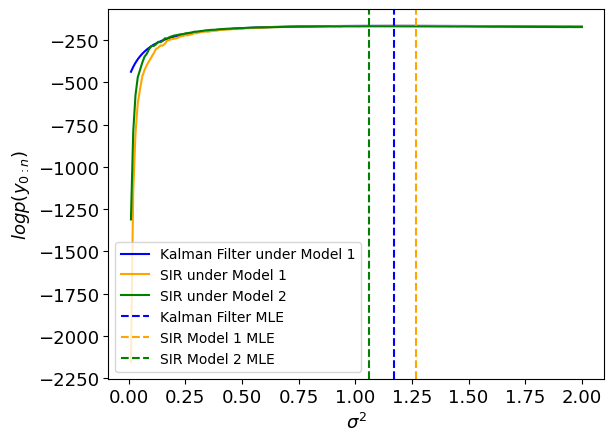

In [236]:
plt.plot(sigma2_values, likelihoods_a, color="blue",label="Kalman Filter under Model 1")
plt.plot(sigma2_values, likelihoods11, color="orange",label="SIR under Model 1")
plt.plot(sigma2_values, likelihoods21, color="green",label="SIR under Model 2")
plt.axvline(mle_a, color="blue",linestyle="--",label="Kalman Filter MLE")
plt.axvline(mle11, color="orange",linestyle="--",label="SIR Model 1 MLE")
plt.axvline(mle21, color="green", linestyle="--",label="SIR Model 2 MLE")
plt.xlabel(r"$\sigma^2$",fontsize=13)
plt.ylabel(r"$logp(y_{0:n})$",fontsize=13)
plt.legend(fontsize=10)
plt.tick_params(labelsize=13)

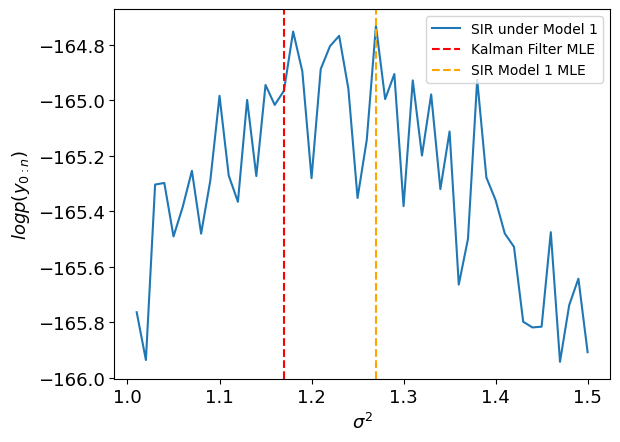

In [239]:
plt.plot(sigma2_values[100:150],likelihoods11[100:150],label="SIR under Model 1")
plt.axvline(mle_a,color="red",linestyle="--",label="Kalman Filter MLE")
plt.axvline(mle11,color="orange",linestyle="--",label="SIR Model 1 MLE")
plt.xlabel(r"$\sigma^2$",fontsize=13)
plt.ylabel(r"$logp(y_{0:n})$",fontsize=13)
plt.legend(fontsize=10)
plt.tick_params(labelsize=13)

For dataset 2:

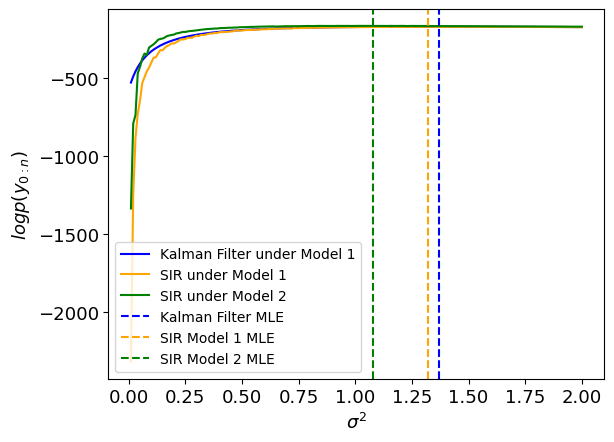

In [238]:
plt.plot(sigma2_values, likelihoods_b, color="blue",label="Kalman Filter under Model 1")
plt.plot(sigma2_values, likelihoods12, color="orange",label="SIR under Model 1")
plt.plot(sigma2_values, likelihoods22, color="green",label="SIR under Model 2")
plt.axvline(mle_b, color="blue",linestyle="--",label="Kalman Filter MLE")
plt.axvline(mle12, color="orange",linestyle="--",label="SIR Model 1 MLE")
plt.axvline(mle22, color="green", linestyle="--",label="SIR Model 2 MLE")
plt.xlabel(r"$\sigma^2$",fontsize=13)
plt.ylabel(r"$logp(y_{0:n})$",fontsize=13)
plt.legend(fontsize=10)
plt.tick_params(labelsize=13)

Thoughts for dataset 1:

- The Kalman Filter provides the true MLE. This is not the same as the true parameter value $\sigma^2=1$ because the Maximum Likelihood Estimator is biased with a finite length of dataset (here we have $T=100$). As the length of the dataset increases, the MLE should go to 1.
- The MLE estimated by SIR is very similar to the Kalman filter, because the SIR filter approximates the Kalman filter very well.
- When we use model 2 on dataset 1, we get a different MLE. This is because model 2 is quite different from dataset 1.

Thoughts for dataset 2:

- The Kalman filter does not accurately estimate the MLE, because the model is not close to a linear Gaussian, so the Kalman Filter does not work that well (is this actually true?)
- The MLE estimated by SIR under model 1 is again very similar to the Kalman Filter.
- The MLE estimated by SIR under model 2 is reasonably different and probably closer to the true value.

In [210]:
print("Dataset 1: Kalman Filter (Model 1): " + str(mle_a))
print("Dataset 1: SIR Model 1: " + str(mle11))
print("Dataset 1: SIR Model 2: " + str(mle21))
print("Dataset 2: Kalman Filter (Model 1): " + str(mle_b))
print("Dataset 2: SIR Model 1: " + str(mle12))
print("Dataset 2: SIR Model 2: " + str(mle22))

Dataset 1: Kalman Filter (Model 1): 1.17
Dataset 1: SIR Model 1: 1.27
Dataset 1: SIR Model 2: 1.06
Dataset 2: Kalman Filter (Model 1): 1.37
Dataset 2: SIR Model 1: 1.32
Dataset 2: SIR Model 2: 1.08


#### EM Algorithm

To implement the EM algorithm, we need to:
- Run SIR Filter/Filter + Smoother to get the particles
- Using the smoothed additive functional, it can be shown that the parameter maximising the value (see handwritten maths) is:

$ \hat{\sigma^2} = \frac{1}{TN} \sum_{i=1}^N \sum_{k=0}^T \frac{(y_k - x_k^i)^2}{e^{x_k^i}}$

- Repeat over many iterations and the parameter should converge to the MLE



In [33]:
def log_f(x,x_prev,rho,tau):

    mean = rho*x_prev
    var = tau**2
    
    val = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(x-mean)**2
    
    return val

In [34]:
def estimate_parameter(y,X):

    T = X.shape[1]
    N = X.shape[0]

    # y_matrix = np.tile(y,(N,1))
    # summand = (y_matrix - X)**2/np.exp(X)

    # # Use np.sum() to sum over both axes at once
    # estimate = 1/(T*N)*np.sum(summand)

    estimate = np.mean(np.mean((y-X)**2/np.exp(X),axis=1))

    return estimate

In [35]:
def FFBSa(y,N,n_paths,sigma2,run_number):

    # Get length of observations
    T = len(y)

    # Set known static parameters
    rho = 0.8
    tau = 0.5

    # Run SIR forwards once
    unnormalised_weights, X, samples, weights = SIR(y,N,sigma2,model=2,run_number=run_number)

    new_samples = np.zeros((n_paths,T))

    # For n_paths particles
    for i in range(n_paths):

        # Sample starting particle from final distribution with replacement
        rng1 = np.random.default_rng(run_number+i)
        index = stats.randint.rvs(0,N,random_state=rng1)
        new_samples[i,T-1] = samples[index,T-1]

        # Recursively sample particles at each timestep to generate new lineage
        for j in range(2,T+1):
            n = T-j

            # Calculate probabilities using sample from next time step
            log_p = np.log(weights[:,n]) + log_f(new_samples[i,n],samples[:,n-1],rho,tau)
            max_val = np.max(log_p)
            p = np.exp(log_p-max_val)/np.sum(np.exp(log_p-max_val))

            # Sample a new ancestor from probabilities and add it to new samples
            rng2 = np.random.default_rng(run_number+i*j+j)
            ancestor_index = stats.multinomial.rvs(1,p,random_state=rng2)
            new_samples[i,n] = samples[ancestor_index==1,n]

    return new_samples

In [36]:
def EM(y,iters,sigma2_init,smoother=False):

    parameter_estimates = [sigma2_init]

    for i in range(1,iters):
        current_param = parameter_estimates[-1]
        if smoother:
            X = FFBSa(y,N=100,n_paths=100,sigma2=current_param,run_number=i)
        else:
            unnormalised_weights, X, samples, weights = SIR(y,N=100,sigma2=current_param,model=2,run_number=i)
            
        next_estimate = estimate_parameter(y,X)
        parameter_estimates.append(next_estimate)

    return parameter_estimates

a) Using starting value = 0.4:

In [211]:
parameter_estimates_SIR1 = EM(y2,iters=100,sigma2_init=0.4,smoother=False)

In [212]:
parameter_estimates_FFBSa1 = EM(y2,iters=100,sigma2_init=0.4,smoother=True)

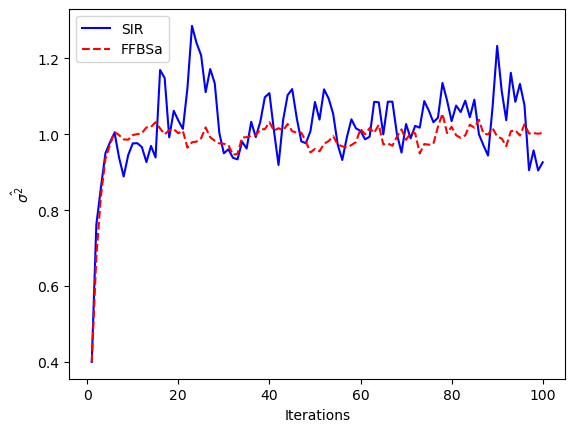

In [213]:
timesteps = np.arange(1,101)
plt.plot(timesteps,parameter_estimates_SIR1,color="blue",label="SIR")
plt.plot(timesteps,parameter_estimates_FFBSa1,color="red",linestyle="--",label="FFBSa")
plt.xlabel("Iterations")
plt.ylabel(r"$\hat{\sigma^2}$")
plt.legend()

MLE estimates:

In [214]:
converged_estimates_SIR1 = parameter_estimates_SIR1[2:]
converged_estimates_FFBSa1 = parameter_estimates_FFBSa1[2:]

In [215]:
mean_SIR1 = np.mean(converged_estimates_SIR1)
sd_SIR1 = np.sqrt(np.var(converged_estimates_SIR1))

In [216]:
mean_FFBSa1 = np.mean(converged_estimates_FFBSa1)
sd_FFBSa1 = np.sqrt(np.var(converged_estimates_FFBSa1))

In [217]:
print(mean_SIR1)
print(sd_SIR1)
print(mean_FFBSa1)
print(sd_FFBSa1)

1.0332174106207779
0.08071497371991558
0.9936273585358117
0.02707634884822835


b) Using starting value = 1.6:

In [139]:
parameter_estimates_SIR2 = EM(y2,iters=100,sigma2_init=1.6,smoother=False)
parameter_estimates_FFBSa2 = EM(y2,iters=100,sigma2_init=1.6,smoother=True)

Text(0, 0.5, '$\\hat{\\sigma^2}$')

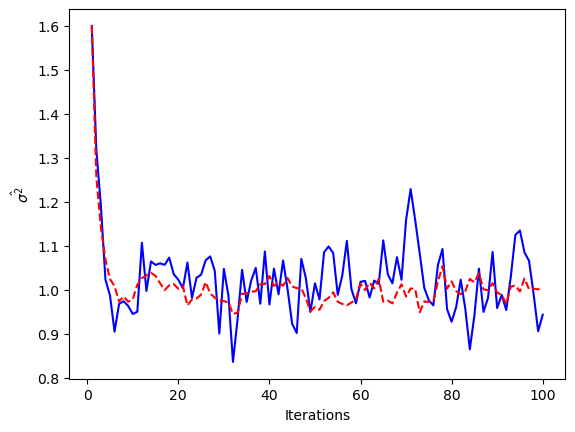

In [140]:
timesteps = np.arange(1,101)
plt.plot(timesteps,parameter_estimates_SIR2,color="blue",label="SIR")
plt.plot(timesteps,parameter_estimates_FFBSa2,color="red",linestyle="--",label="FFBSa")
plt.xlabel("Iterations")
plt.ylabel(r"$\hat{\sigma^2}$")

MLE Estimates:

In [76]:
converged_estimates_SIR2 = parameter_estimates_SIR2[3:]
converged_estimates_FFBSa2 = parameter_estimates_FFBSa2[4:]

In [77]:
mean_SIR2 = np.mean(converged_estimates_SIR2)
sd_SIR2 = np.sqrt(np.var(converged_estimates_SIR2))

In [78]:
mean_FFBSa2 = np.mean(converged_estimates_FFBSa2)
sd_FFBSa2 = np.sqrt(np.var(converged_estimates_FFBSa2))

In [79]:
print(mean_SIR2)
print(sd_SIR2)
print(mean_FFBSa2)
print(sd_FFBSa2)

1.0410691825535277
0.0776071590227667
1.1252433161688904
0.02574078347387549
